# Explainability Plots

In [26]:
import warnings
import joblib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

from pathlib import Path
import shutil
from datetime import datetime
import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load / Reload Selection Utility Functions

In [27]:
from utils2 import explainability as exp

----

## Read Config File

In [28]:
config_path = Path(r'experiments')
config_filename =  "bin_exp_final_auprc_f2.yml"
config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict


{'experiment': {'summary': 'binary classification - Explainability Analysis (development)',
  'classification_type': 'binary',
  'stage': 'explainability',
  'tag': 'final_auprc_f2',
  'verbosity': 1,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'model': {'code': 'catboost', 'name': 'CatBoost'},
 'param_space': {'iterations': {'min': 100, 'max': 500},
  'depth': {'min': 4, 'max': 10},
  'learning_rate': {'min': 0.01, 'max': 0.1},
  'l2_leaf_reg': {'min': 1, 'max': 9}},
 'hpo_results': {'file': 'binary\\hyperparameter_optimization\\CatBoost\\final\\optimization_results.json',
  'threshold': 0.6352084424142594},
 'optimization': {'k_splits_outer': 3,
  'k_splits_inner': 3,
  'n_iter': 5,
  'optimization_metric': 'auprc',
  'threshold_selection_metric': 'fscore',
  'fscore_beta': 2}}

#### Set output directory

In [29]:
outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.model.code / config.experiment.tag 
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\explainability\catboost\final_auprc_f2


#### Copy config file to output directory

In [30]:
source = config_path / config_filename
destination = outputdir / config_filename
shutil.copy(source, destination)

WindowsPath('experiments/binary/explainability/catboost/final_auprc_f2/bin_exp_final_auprc_f2.yml')

## Data Loading

In [31]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type)

dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
no_ncs_datacols = [c for c in data_cols if c not in D.ncs_cols]
X = dfdpn[no_ncs_datacols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 22), (190,))

## k-fold Optimization

In [32]:
ksplit_trained_models =  exp.get_ksplit_trained_models(
    X, y, config,
    savedir=outputdir, 
    overwrite=False,
    )

catboost_ksplit_trained_models.joblib exists. Returning values from contents.


In [33]:
ksplit_trained_models.keys()

dict_keys(['results', 'summary', 'rundate', 'tag'])

In [34]:
ksplit_trained_models['rundate'], ksplit_trained_models['tag']

('2026-04-13', 'final_auprc_f2')

In [35]:
ksplit_trained_models["summary"]


,threshold,accuracy,precision,sensitivity,specificity,f1,f1.25,f1.5,f1.75,f2,youden,roc-auc,auprc
0,0.049,0.688,0.688,1.000,0.0,0.815,0.849,0.877,0.899,0.917,0.000,0.836,0.896
1,0.284,0.810,0.782,1.000,0.4,0.878,0.902,0.921,0.936,0.947,0.400,0.871,0.927
2,0.270,0.794,0.778,0.977,0.4,0.866,0.888,0.905,0.919,0.929,0.377,0.809,0.901


## Analysis Plots

In [36]:
split_results = ksplit_trained_models['results']
split_results

[{'model': <catboost.core.CatBoostClassifier at 0x121f2651340>,
  'threshold': 0.048653816595108694,
  'best_params': OrderedDict([('depth', 6),
               ('iterations', 391),
               ('l2_leaf_reg', 8.462943990782671),
               ('learning_rate', 0.02069186296126172)]),
  'X_train':      SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
  0      1  64.0     1     7.0      1.0  15.00    0     0         0    0    0   
  1      0  59.0     1     1.0      0.0   5.60    1     0         0    0    0   
  5      0  20.0     1     2.0      1.0   7.80    0     0         0    0    0   
  6      0  69.0     0     0.0      0.0   8.00    1     0         1    0    0   
  7      0  60.0     0     2.0      0.0   5.80    1     0         0    0    0   
  8      1  62.0     0     0.0      1.0  14.36    0     0         0    0    0   
  9      0  44.0     1    17.0      0.0   7.01    0     0         0    0    0   
  10     0  70.0     0    10.0      0.0   6.40    1 

### Feature Importance

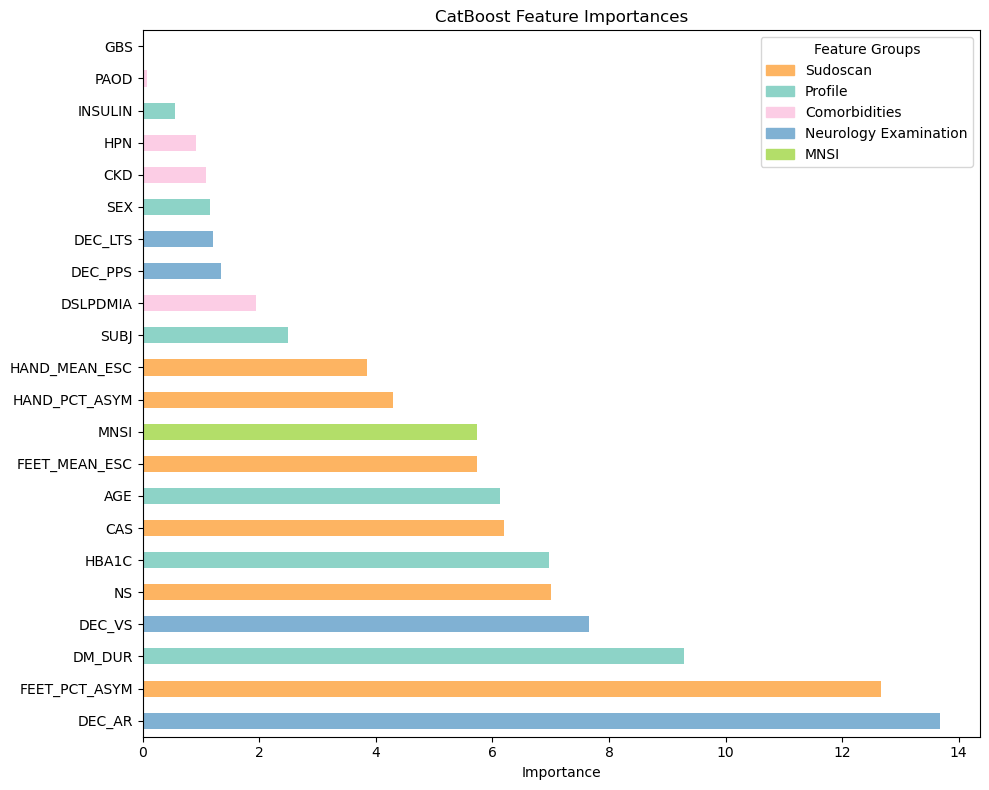

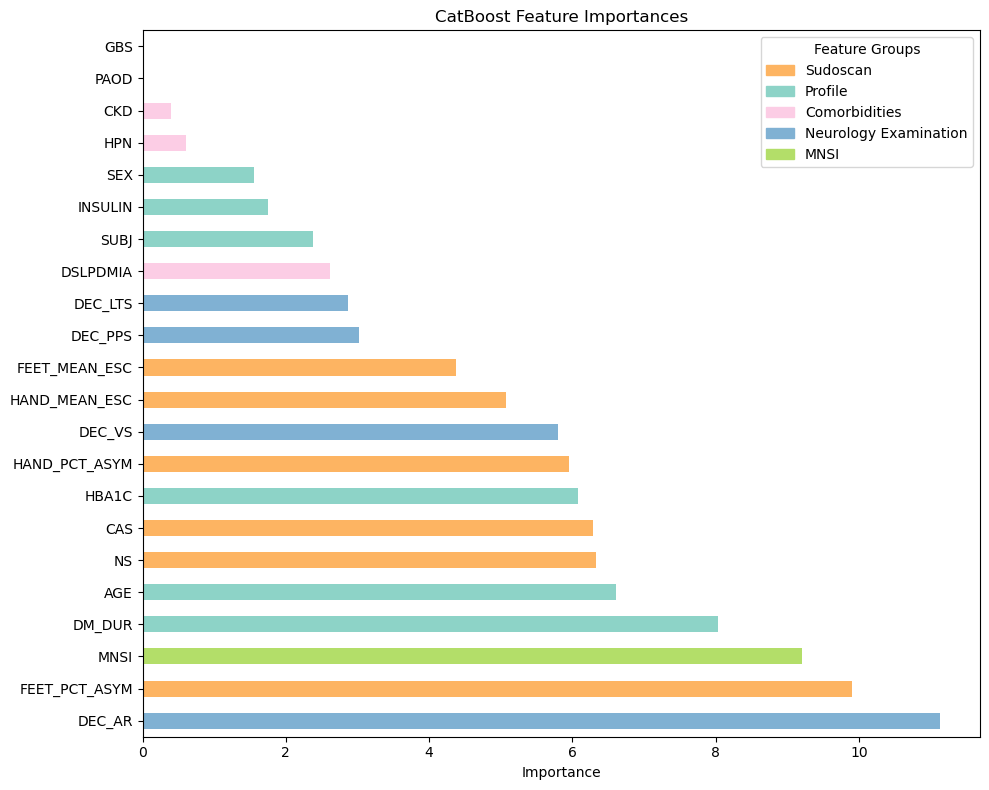

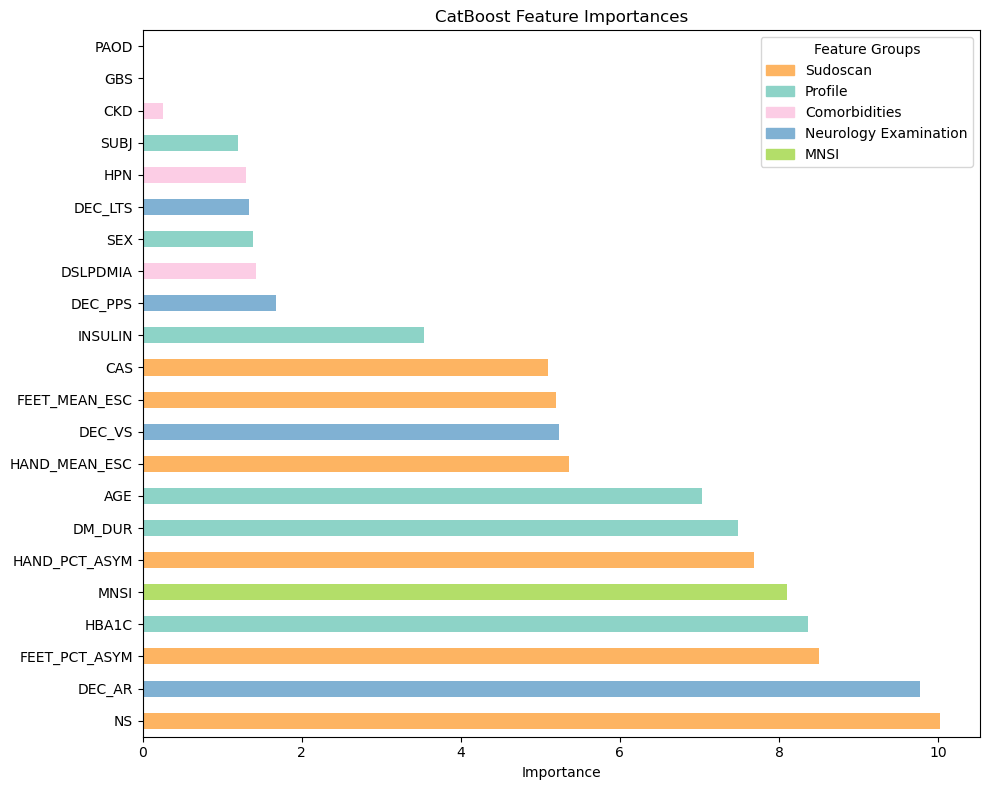

In [37]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    feature_names = X.columns
    exp.plot_importances(D, model, s, feature_names, config, 
                        minimum=None, limit=None, 
                        savedir=outputdir)    

#### AUPRC Curve

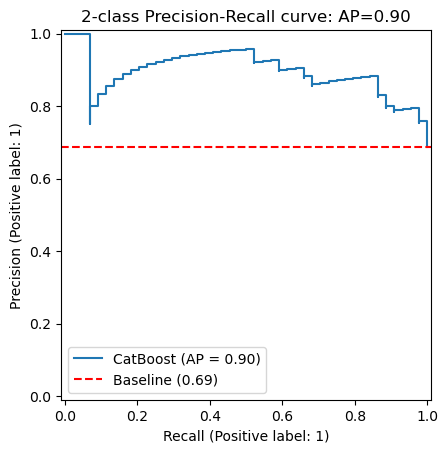

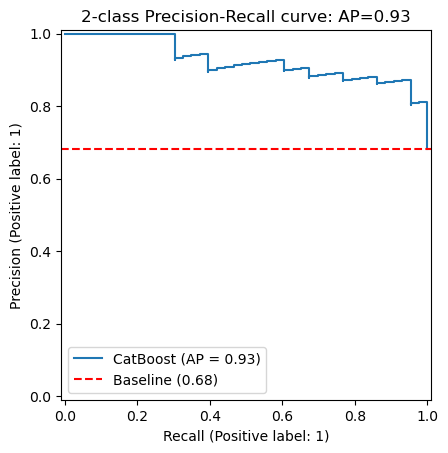

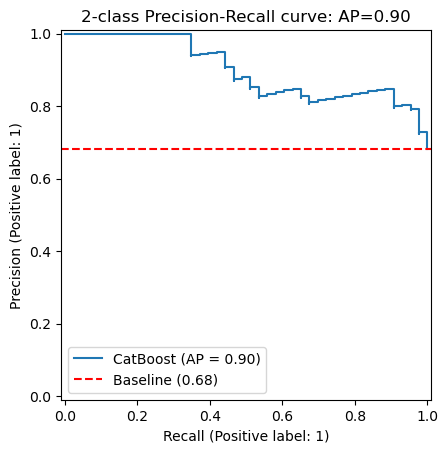

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay

for s in range(len(split_results)): 
    model = split_results[s]['model']
    X_test = split_results[s]['X_test']
    y_test = split_results[s]['y_test']
    y_proba = model.predict_proba(X_test)[:,1]# y_test: true labels
    # y_scores: predicted probabilities for the positive class
    average_precision = average_precision_score(y_test, y_proba)

    # Create the plot
    display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="CatBoost")
    _ = display.ax_.set_title(f"2-class Precision-Recall curve: AP={average_precision:.2f}")

    # Add the 'No-Skill' baseline (prevalence of positive class)
    baseline = sum(y_test) / len(y_test)
    plt.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')

    plt.legend()
    plt.show()

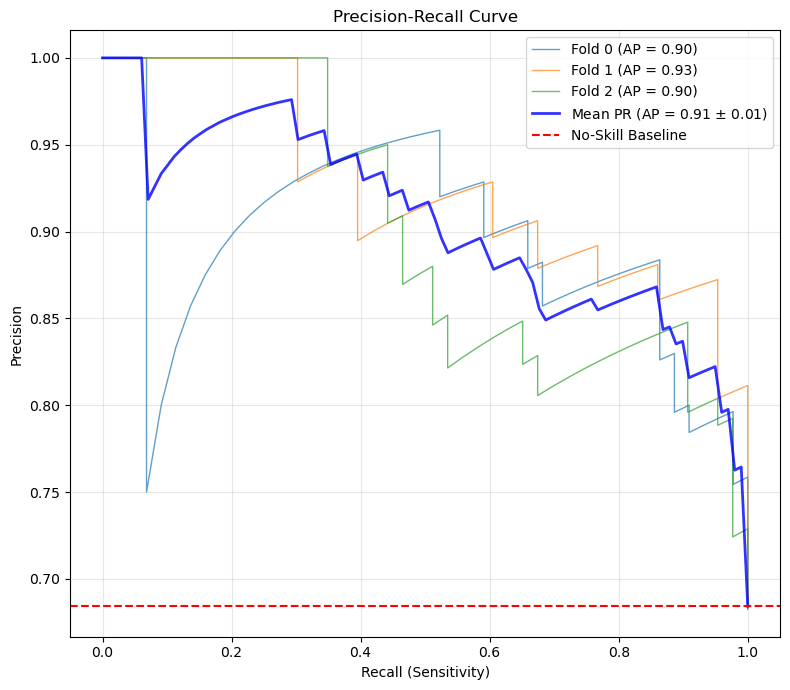

In [43]:
y_test_list = []
y_proba_list = []
for s in range(len(split_results)): 
    model = split_results[s]['model']
    X_test = split_results[s]['X_test']
    y_test = split_results[s]['y_test']
    y_proba = model.predict_proba(X_test)[:,1]# y_test: true labels
    y_test_list.append(y_test)
    y_proba_list.append(y_proba)
exp.plot_cv_auprc(y_test_list, y_proba_list, config, savedir=outputdir)

#### ROC Curve

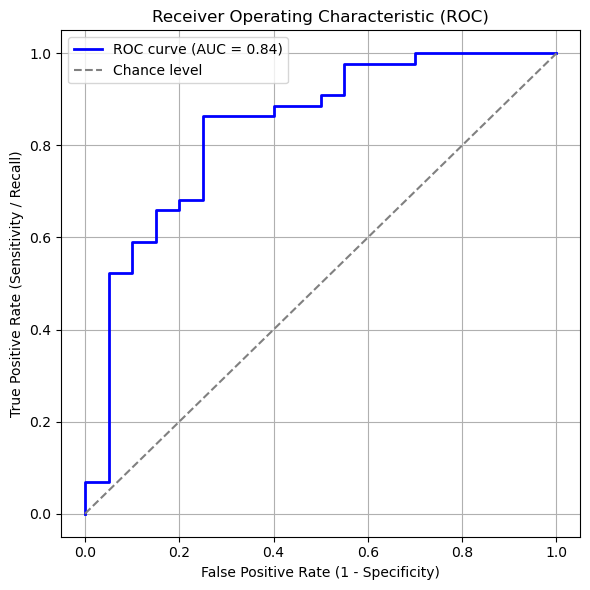

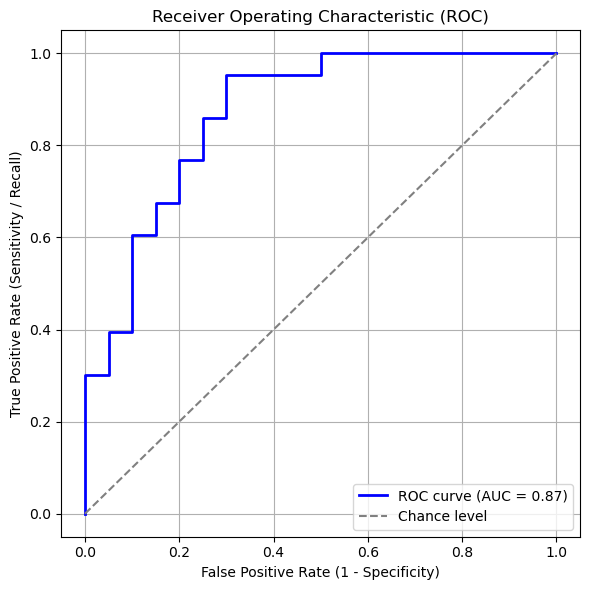

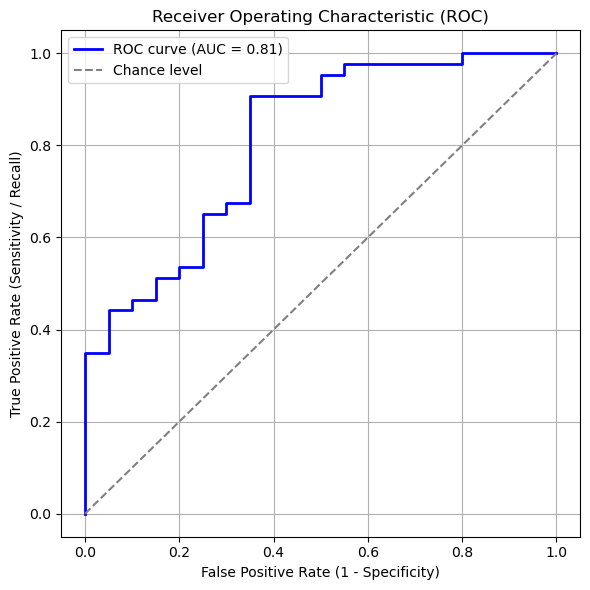

In [40]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    X_test = split_results[s]['X_test']
    y_test = split_results[s]['y_test']
    y_proba = model.predict_proba(X_test)[:,1]
    exp.plot_roc_auc(y_test, y_proba, s, config, outputdir);    


### DCA

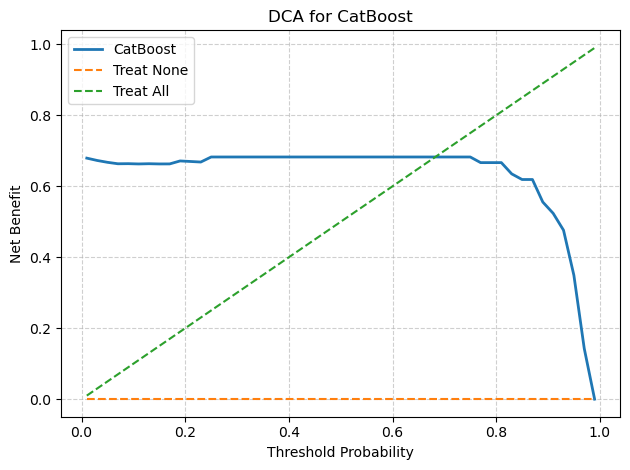

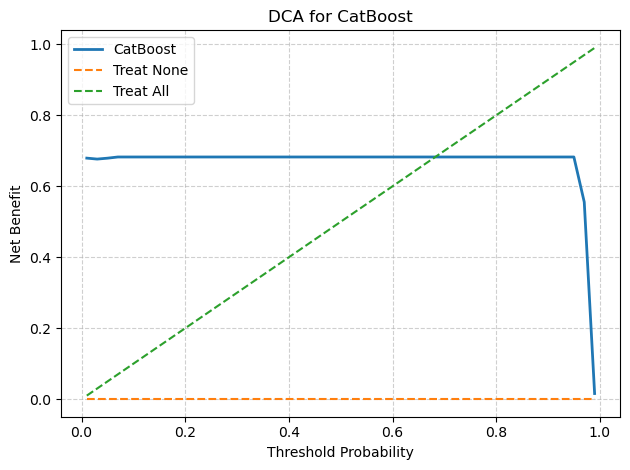

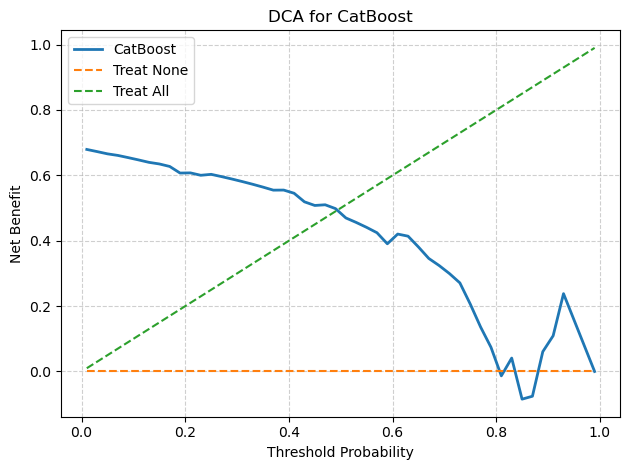

In [41]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    thresholds, nb = exp.plot_decision_curve_analysis(model, s, X_test, y_test, config, savedir=outputdir)

## SHAP Analysis

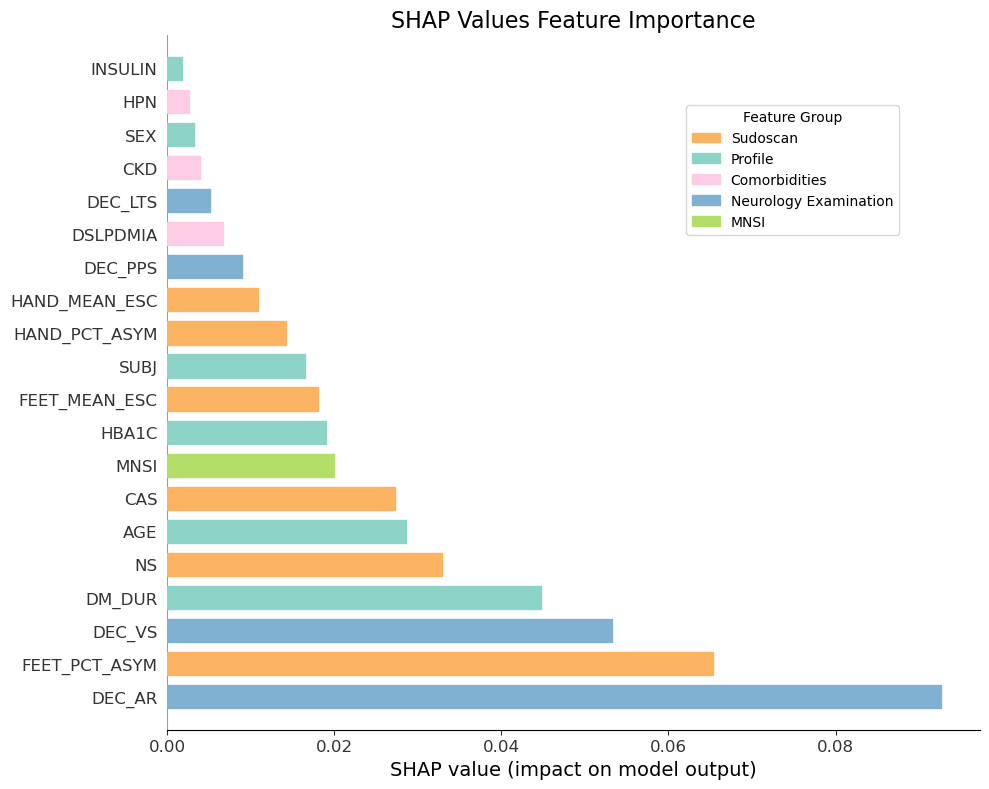

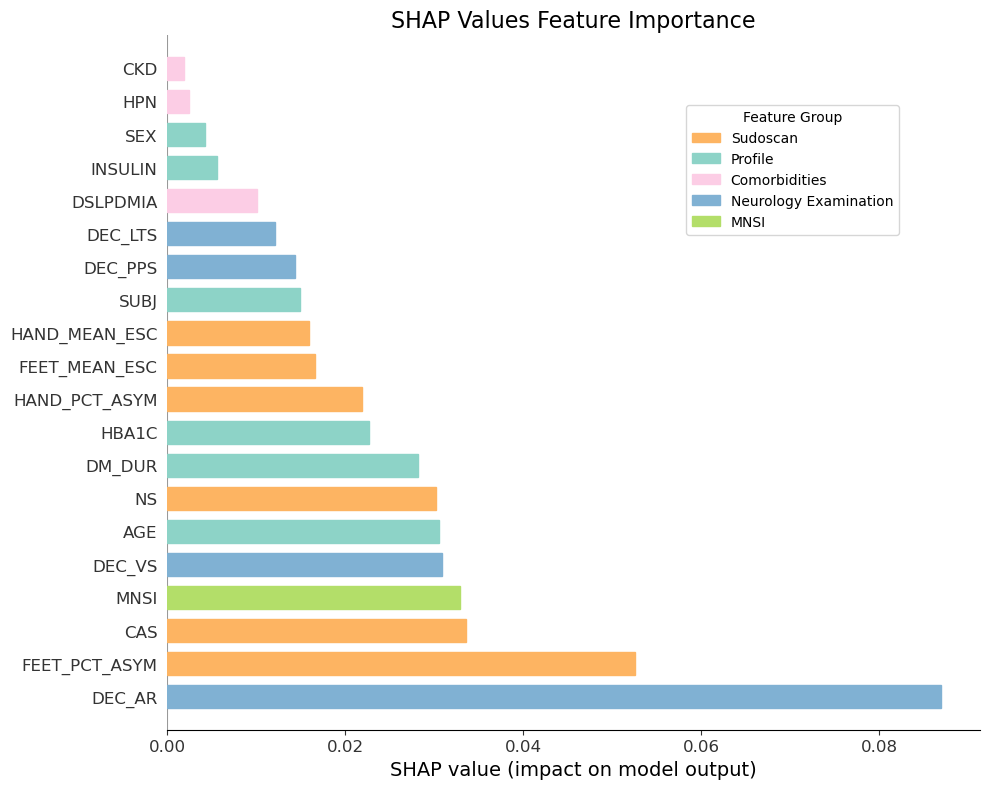

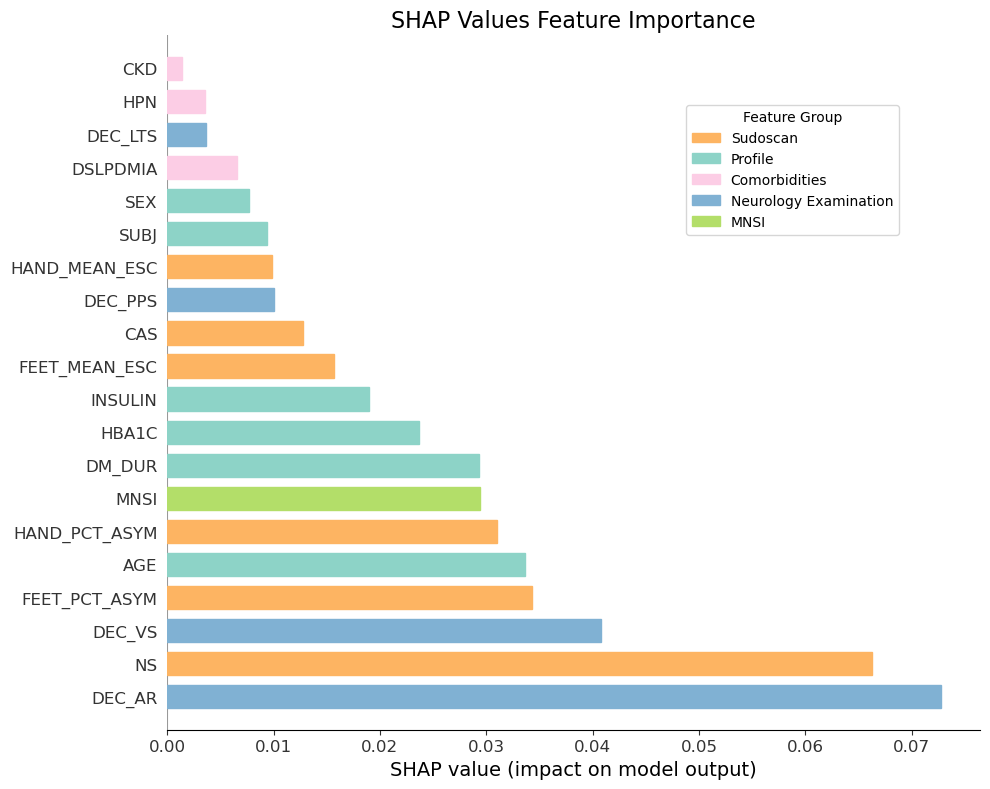

In [42]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    exp.plot_shap(D, model, s, config, X_test, savedir=outputdir)

## Sensitivity Sensitivity Test

In [52]:
metric_files = [outputdir.parent / f'final_auprc_{s}'/ 'catboost_ksplit_trained_models_metrics.csv' for s in ['f1','f125','f15','f175','f2']]
metric_files

[WindowsPath('experiments/binary/explainability/catboost/final_auprc_f1/catboost_ksplit_trained_models_metrics.csv'),
 WindowsPath('experiments/binary/explainability/catboost/final_auprc_f125/catboost_ksplit_trained_models_metrics.csv'),
 WindowsPath('experiments/binary/explainability/catboost/final_auprc_f15/catboost_ksplit_trained_models_metrics.csv'),
 WindowsPath('experiments/binary/explainability/catboost/final_auprc_f175/catboost_ksplit_trained_models_metrics.csv'),
 WindowsPath('experiments/binary/explainability/catboost/final_auprc_f2/catboost_ksplit_trained_models_metrics.csv')]

In [53]:
dfs = [pd.read_csv(f) for f in metric_files]

In [ ]:
specificity_means = [df.specificity.mean() for df in dfs]
sensitivity_means = [df.sensitivity.mean() for df in dfs]
betas = [1,1.25,1.5,1.75,2.0]

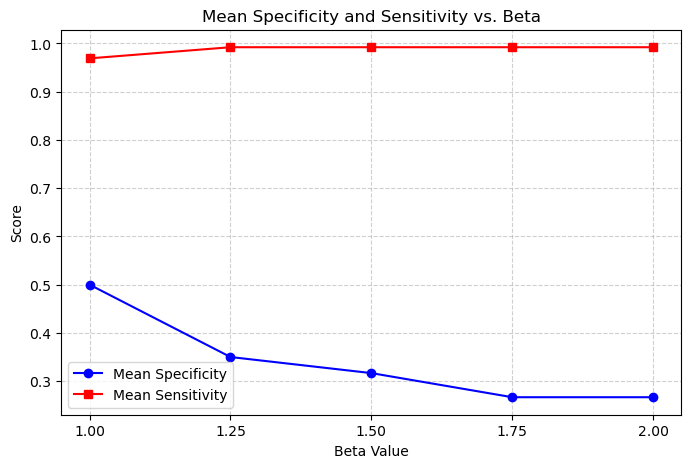

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(betas, specificity_means, marker='o', label='Mean Specificity', color='blue')
plt.plot(betas, sensitivity_means, marker='s', label='Mean Sensitivity', color='red')

# Add labels and legend
plt.title('Mean Specificity and Sensitivity vs. Beta')
plt.xlabel('Beta Value')
plt.ylabel('Score')
plt.xticks(betas) # Ensures all beta values show on the x-axis
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()